# Lab 3: Non-parametric estimation

# Task 1: Nonparametric Estimation: Kernels

## 1. Introduction

In **nonparametric estimation**, we try to estimate an unknown function $f(x)$ from data without assuming a fixed parametric form (like linear or polynomial regression).  
Instead of fitting global parameters, we use **local information** — nearby data points have more influence on the prediction at a given $ x $.

A common approach to nonparametric regression is **kernel regression**, where we estimate the regression function as a *weighted average* of observed values:

$$
\hat{f}(x) = \frac{\sum_{i=1}^n K(x, x_i) \, y_i}{\sum_{i=1}^n K(x, x_i)}.
$$

Here, $ K(x, x_i) $ is called a **kernel function** — it measures the *similarity* or *closeness* between the query point $ x $ and training point $ x_i $.

---

## 2. What is a Kernel?

A **kernel** is a function that takes two inputs $x $ and $ z$ and returns a number that represents how “close” or “similar” they are.

Formally, a kernel is:

$$
K(x, z): \mathbb{R}^d \times \mathbb{R}^d \to \mathbb{R}
$$

with the properties:
- $ K(x, z) = K(z, x) $ (symmetry)
- $ K(x, z) \ge 0 $ (non-negative, for most similarity kernels)

---

## 3. Kernels You Will Implement

In this task, you’ll implement several common kernel functions used in nonparametric regression.

| Kernel | Function Name | Equation / Description |
|---------|----------------|-----------------------|
| **Boxcar (Uniform)** | `kernel_boxcar(x, z, width)` | $ K(x, z) = \mathbf{1}(|x - z| \le \text{width}) $ |
| **RBF (Gaussian)** | `kernel_rbf(x, z, gamma)` | $ K(x, z) = \exp(-\gamma \|x - z\|^2) $ |
| **Linear** | `kernel_linear(x, z)` | $ K(x, z) = x^\top z $ |
| **Polynomial** | `kernel_polynomial(x, z, d)` | $ K(x, z) = (1 + x^\top z)^d $ |

---


### Task 1.1 (4 points)

Complete the function definitions below. You will get 1 point for each correctcly **completed** function.

In [1]:
import numpy as np

# 1. Boxcar (Uniform) Kernel
def kernel_boxcar(x, z, width):
    """
    Boxcar / Uniform kernel.
    Returns 1 if |x - z| <= width, else 0.
    """
    # TODO: Implement this
    return (np.abs(x - z) <= width).astype(float)


# 2. RBF (Gaussian) Kernel
def kernel_rbf(x, z, gamma):
    """
    Radial Basis Function (Gaussian) kernel.
    Measures similarity that decays exponentially with squared distance.
    """
    # TODO: Implement this
    diff = x - z
    return np.exp(-gamma * np.dot(diff, diff))



# 3. Linear Kernel
def kernel_linear(x, z):
    """
    Linear kernel.
    Simply the inner product between x and z.
    """
    # TODO: Implement this
    return np.dot(x, z)



# 4. Polynomial Kernel
def kernel_polynomial(x, z, d):
    """
    Polynomial kernel.
    Expands similarity to higher dimensions via (1 + x^T z)^d.
    """
    # TODO: Implement this
    return (1 + np.dot(x.T, z)) ** d


#### Test your functions


**Expected ouput**:

- Boxcar: [1. 1.]
- RBF: 0.6065306597126334
- Linear: 6.5
- Polynomial: 56.25



In [2]:
x = np.array([1.0, 2.0])
z = np.array([1.5, 2.5])

print("Boxcar:", kernel_boxcar(x, z, width=1.0))
print("RBF:", kernel_rbf(x, z, gamma=1.0))
print("Linear:", kernel_linear(x, z))
print("Polynomial:", kernel_polynomial(x, z, d=2))


Boxcar: [1. 1.]
RBF: 0.6065306597126334
Linear: 6.5
Polynomial: 56.25


### Task 1.2 (2 points)

In this task, you will *compare the geometry* of two contrasting kernels — **Linear** and **RBF (Gaussian)** — by visualizing how their similarity function  
$$
K(x, z)
$$
behaves across a 2D space for a fixed reference point $ z $.

You will:
1. Compute $ K(x, z) $ on a grid of 2D points for each kernel,  
2. Draw **contour plots** showing lines of equal similarity to the reference point using ```plt.contour```.



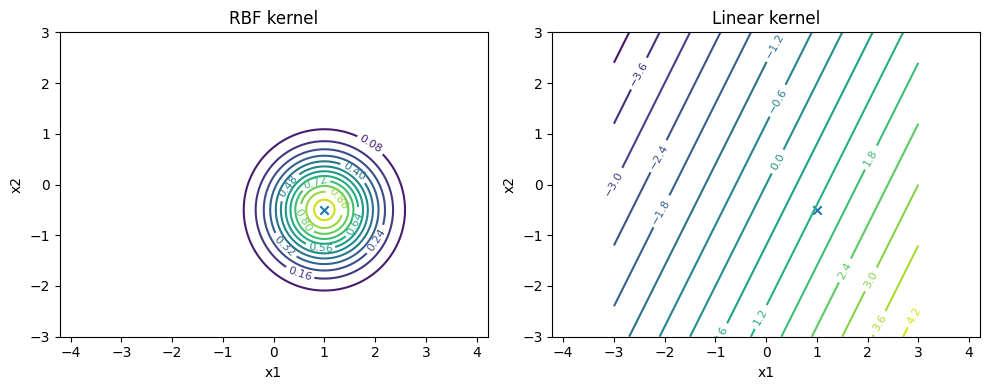

In [3]:

import numpy as np
import matplotlib.pyplot as plt

# --- Your kernel functions are assumed defined above ---
# kernel_rbf(x, z, gamma)
# kernel_linear(x, z)

def similarity_map(kernel_fn, z, x_range=(-2, 2), y_range=(-2, 2), n_points=200, **params):
    """
    Computes a 2D grid of kernel similarity values K(x, z).

    Parameters
    ----------
    kernel_fn : function
        The kernel function to evaluate, e.g., kernel_rbf or kernel_linear.
    z : np.ndarray
        The reference point (2D vector).
    x_range, y_range : tuple of floats
        Range of x1 and x2 axes for the grid.
    n_points : int
        Number of grid points per axis.
    params : dict
        Additional keyword arguments (e.g., gamma for RBF).

    Returns
    -------
    X, Y : np.ndarray
        Meshgrid of coordinates.
    M : np.ndarray
        Matrix of similarity values K(x, z).
    """
    # Create grid
    xs = np.linspace(*x_range, n_points)
    ys = np.linspace(*y_range, n_points)
    X, Y = np.meshgrid(xs, ys)

    # Allocate output matrix
    M = np.zeros_like(X, dtype=float)

    # Loop over grid and compute K(x_vec, z)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            x_vec = np.array([X[i, j], Y[i, j]])
            # TODO: complete function calls
            if params:
                M[i, j] = kernel_fn(x_vec, z, **params)
            else:
                M[i, j] = kernel_fn(x_vec, z)

    return X, Y, M


z = np.array([1.0, -0.5])

# TODO: compute similarity maps
# Hint: RBF takes gamma; Linear does not.
X, Y, M_rbf = similarity_map(kernel_rbf, z, x_range=(-3, 3), y_range=(-3, 3), n_points=200, gamma=1.0)
_, _, M_lin = similarity_map(kernel_linear, z, x_range=(-3, 3), y_range=(-3, 3), n_points=200)

# Plot the contour maps side by side.
# Plot reference point on each plot

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
# TODO: draw contours for RBF
contours_rbf = plt.contour(X, Y, M_rbf, levels=15)
plt.clabel(contours_rbf, inline=True, fontsize=8)
plt.scatter(z[0], z[1], marker='x')
plt.title('RBF kernel')
plt.xlabel('x1'); plt.ylabel('x2'); plt.axis('equal')

plt.subplot(1, 2, 2)
# TODO: draw contours for Linear
contours_linear = plt.contour(X, Y, M_lin, levels=15)
plt.clabel(contours_linear, inline=True, fontsize=8)
plt.scatter(z[0], z[1], marker='x')
plt.title('Linear kernel')
plt.xlabel('x1'); plt.ylabel('x2'); plt.axis('equal')

plt.tight_layout()
plt.show()


# Task 1.3 (1 point)

After visualizing both kernels, describe how the shape of the similarity contours differs between the Linear and RBF (Gaussian) kernels.
How does each kernel define what it means for two points to be “similar”?
What do the contour shapes tell you about how each kernel generalizes beyond the reference point?


**YOUR ANSWER HERE**
 - The Linear kernel:
   - It produces straight, parallel contour lines.
   - This means that similarity depends on the directional alignment between x and z rather than distance, i.e., points lying on the same side of z along the direction of z have higher similarity, while those on the opposite side have lower or even negative similarity.
   - It does not decay with distance but instead reflects how well the vectors point in the same direction, so the Linear kernel generalizes globally.
 - The RBF kernel:
   - It produces circular contour lines centered around the reference point z.
   - This means that similarity depends only on the distance between x and z, i.e., points that are equally far from z in any direction have the same similarity.
   - As x moves farther away from z, the kernel value decreases toward 0, so the RBF kernel defines similarity locally and generalizes only to nearby points.

# Task 2: Applying kernel regression


In this task you will implement, visualize, and evaluate a **non-parametric kernel regression model** on the airport operations dataset.

## Task 2.1 Data loading and preprocessing (1 pt)

In this step, we begin by loading the dataset from `airport_operations_report.csv`. 

From the data, we select **“General Aviation: Total Operations”** as the target variable \(Y\), and two covariates \(X\): **“Air Carrier Operations”** and **“General Aviation: Local Operations.”** 

To make the magnitudes comparable, we apply scaling: the first covariate is divided by 1000, the second by 100, and the target by 1000. 

After preprocessing, construct a two-dimensional grid over the range of both covariates, where each axis spans from its minimum to maximum value and contains 100 evenly spaced points. 

In [4]:
# Your code
import pandas as pd
df = pd.read_csv("../src/data/csv/airport_operations_report.csv")
col_x1 = "Air Carrier Operations"
col_x2 = "General Aviation: Local Operations"
col_y  = "General Aviation: Total Operations"

# preprocessing
df = df[[col_x1, col_x2, col_y]].dropna()
x1 = df[col_x1].to_numpy(dtype=float)
x2 = df[col_x2].to_numpy(dtype=float)
y  = df[col_y].to_numpy(dtype=float)
X = np.column_stack([x1 / 1000.0, x2 / 100.0])
Y = y / 1000.0

x1_min, x1_max = X[:, 0].min(), X[:, 0].max()
x2_min, x2_max = X[:, 1].min(), X[:, 1].max()
g1 = np.linspace(x1_min, x1_max, 100)
g2 = np.linspace(x2_min, x2_max, 100)

GX, GY = np.meshgrid(g1, g2)
X_grid = np.column_stack([GX.ravel(), GY.ravel()])

print("X shape:", X.shape, "Y shape:", Y.shape)
print("Grid shapes:", GX.shape, GX.shape, "Flattened:", X_grid.shape)

X shape: (117, 2) Y shape: (117,)
Grid shapes: (100, 100) (100, 100) Flattened: (10000, 2)


## Task 2.2: Kernel regression model (2 pt)

Implement the **Nadaraya–Watson estimator** using a **Gaussian (RBF) product kernel**:

$$
\hat f(x) \;=\;
\frac{\sum_{i=1}^n K_h(x, X_i)\, Y_i}
     {\sum_{i=1}^n K_h(x, X_i) + \lambda}
$$

with

$$
K_h(x, z) \;=\; \exp\!\left(
-\tfrac{1}{2}\sum_{j=1}^2
\left(\frac{x_j - z_j}{h_j}\right)^2
\right).
$$


Here, $h=(h_1,h_2)$ are the bandwidths, and $\lambda$ is a small regularizer.

In [5]:
def gaussian_kernel_pair(x, z, h):
    # Your code
    diff = (x - z) / h
    return np.exp(-0.5 * np.sum(diff * diff))

def predict_kernel_regression(X, X_train, y_train, kernel_function, lamb=1e-6):
    # Your code
    m = X.shape[0]
    y_pred = np.empty(m, dtype=float)

    for k in range(m):
        w = np.array([kernel_function(X[k], xi) for xi in X_train], dtype=float)  # (n,)
        num = np.dot(w, y_train)
        den = np.sum(w) + lamb
        y_pred[k] = num / den
    return y_pred

Predict on the grid with an initial bandwidth, h = (1, 1):

In [6]:
h = np.array([1.0, 1.0]) # Your code
kern = lambda x, z: gaussian_kernel_pair(x, z, h)
y_grid_hat = predict_kernel_regression(X_grid, X, y, kern, lamb=1e-6)
Z = y_grid_hat.reshape(GX.shape)

Visualize the fitted surface using a 3D plot. Describe in 1 sentence the observed shape of the surface (linear or nonlinear, and whether there seems to be any interaction between the two variables)

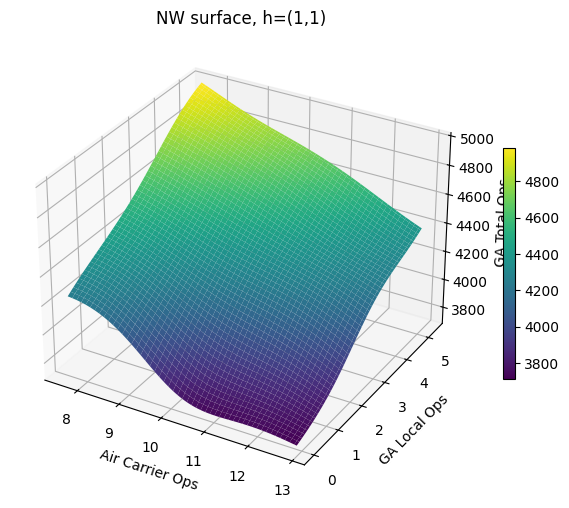

In [7]:
from matplotlib import cm

def plot_surface_function(GX, GY, Z, title="Estimated surface"):
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(GX, GY, Z, cmap=cm.viridis)
    ax.set_xlabel("Air Carrier Ops")
    ax.set_ylabel("GA Local Ops")
    ax.set_zlabel("GA Total Ops")
    ax.set_title(title)
    fig.colorbar(surf, shrink=0.5)
    plt.show()
plot_surface_function(GX, GY, Z, "NW surface, h=(1,1)")

## Task 2.3: Confidence intervals (2 pt)

Construct **95% confidence bands** for your estimated regression surface.

To estimate the **error variance** in the 2D case, for each observation find its **nearest neighbor** (using Euclidean distance) and compute the differences between their target values. The variance estimate can then be obtained from these differences.

To determine the **effective power** for the quantile of the standard normal distribution, use the fraction of the bandwidth relative to the data range:
for each coordinate \(i\), compute $\frac{h_i}{b_i - a_i}$,  
and multiply them together:

$$
\prod_{i=1}^2 \frac{h_i}{b_i - a_i}.
$$

For Gaussian kernels, set $h = 3 \times$ kernel bandwidth.  
Finally, use this to scale the 95% quantile of the standard normal distribution $z_{0.975} = 1.96$ and construct the confidence intervals around your predicted surface.

In [8]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=2).fit(X) # Your code
_, idx = nbrs.kneighbors(X)
nn = idx[:, 1]

sigma2 = 0.5 * np.mean((Y - Y[nn])**2) # Your code
sigma = np.sqrt(sigma2) # Your code

h_mass = 3.0 * h # Your code
rng = X.max(axis=0) - X.min(axis=0) # Your code
frac = np.prod(h_mass / rng)

n_eff = max(frac * len(X), 1e-12) # Your code
z975 = 1.96
ci = z975 * sigma / np.sqrt(n_eff) # Your code

Z_hat = y_grid_hat.reshape(GX.shape) # Your code
Z_lo = Z_hat - ci # Your code
Z_hi = Z_hat + ci # Your code

print(f"sigma² = {sigma2:.4g}, n_eff = {n_eff:.4g}, CI half-width = {ci:.4g}")

sigma² = 0.2512, n_eff = 37.75, CI half-width = 0.1599


# Task 2.4: Bandwidth selection (2 pt)

Use cross-validation to find optimal bandwidths $(h_1, h_2)$.

The objective is the leave-one-out mean squared error:
$$
\mathrm{MSE}(h) = \frac{1}{n}\sum_{i=1}^{n}\big(Y_i - \hat f_{-i}(X_i)\big)^2,
$$
where $\hat f_{-i}$ is the Nadaraya–Watson estimator computed **excluding** the \(i\)-th sample.

**Steps**
1. Define logarithmic grids for the bandwidths:
   $h_1, h_2 \in [0.1, 10]$ with **21** points each.
2. For every pair $(h_1, h_2)$, compute the **LOO-MSE**.
3. Select the pair $h^\star = (h_1^\star, h_2^\star)$ that minimizes the MSE.
4. Visualize the MSE surface over the grid and **mark the optimum**.

In [9]:
def loo_mse_for_bandwidth(X, y, h, lamb=1e-8):
    n = len(X)
    W = np.empty((n, n))
    for i in range(n):
        d = (X[i] - X) / h
        W[i] = np.exp(-0.5 * np.sum(d * d, axis=1))
    np.fill_diagonal(W, 0.0)

    num = W @ y # Your code
    den = W.sum(axis=1) + lamb # Your code
    y_hat = num / den # Your code

    return np.mean((y - y_hat) ** 2) # Your code

h1_grid = np.logspace(-1, 1, 21)
h2_grid = np.logspace(-1, 1, 21)
mse_map = np.zeros((21, 21))

best = {"mse": np.inf, "h": None}

for i, h1 in enumerate(h1_grid):
    for j, h2 in enumerate(h2_grid):
        h = np.array([h1, h2])
        mse = loo_mse_for_bandwidth(X, Y, h) # Your code
        mse_map[i, j] = mse
        if mse < best["mse"]:
            best = {"mse": mse, "h": h}

print("Optimal bandwidths:", best["h"], "MSE:", best["mse"])

Optimal bandwidths: [0.50118723 0.50118723] MSE: 0.23381866372718593


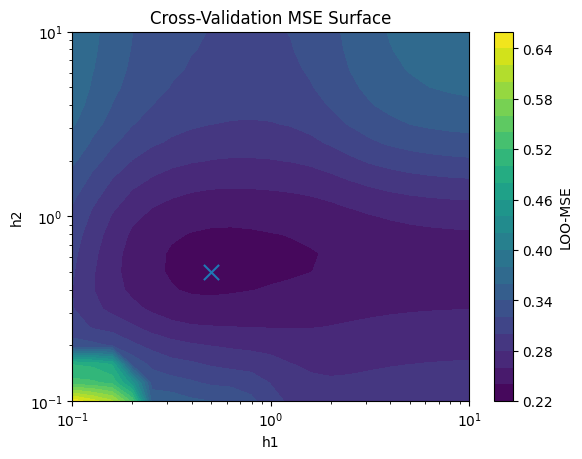

In [10]:
H1, H2 = np.meshgrid(h1_grid, h2_grid, indexing="ij")
plt.contourf(H1, H2, mse_map, levels=20)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("h1"); plt.ylabel("h2")
plt.colorbar(label="LOO-MSE")

# Your code plt.scatter...
plt.scatter(best["h"][0], best["h"][1], marker="x", s=120)

plt.title("Cross-Validation MSE Surface")
plt.show()


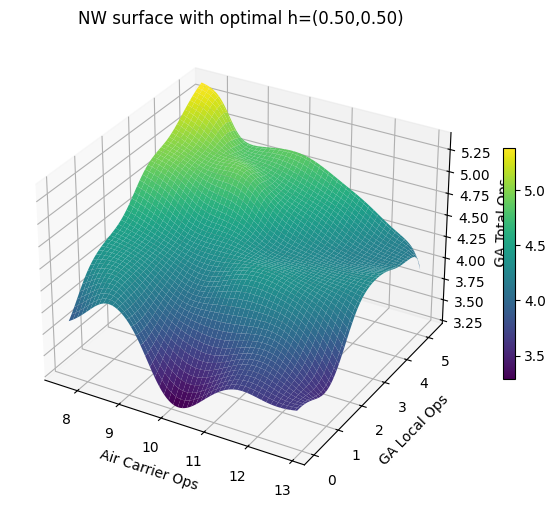

In [11]:
h = best["h"]

kern_best = lambda a, b: gaussian_kernel_pair(a, b, h) # Your code

y_grid_best = predict_kernel_regression(X_grid, X, Y, kern_best, lamb=1e-6) # Your code

Z_best = y_grid_best.reshape(GX.shape)

plot_surface_function(GX, GY, Z_best,
    f"NW surface with optimal h=({h[0]:.2f},{h[1]:.2f})")

# Task 3: Polynomial (Parametric) Regression vs kNN Regression

## Task 3.1: Load and preprocess the data

In this task, we’ll use the Diabetes dataset from sklearn, a standard regression dataset with 10 numeric features.


1. Load dataset.
2. Separate features and target, then standardize features.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Your code here
diab = load_diabetes()
X = diab.data
y = diab.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)

print("Train:", X_train_std.shape, "Test:", X_test_std.shape)

Train: (353, 10) Test: (89, 10)


## Task 3.2 Polynomial Regression (Parametric Model) (2 points)

In this task, we will fit a **parametric model** to the data — specifically, a **Polynomial Regression** model. Polynomial regression extends linear regression by including polynomial combinations of the input features, allowing the model to capture nonlinear relationships while still maintaining a parametric form. To keep the workflow organized, we will use `make_pipeline(PolynomialFeatures, LinearRegression)` from `sklearn.pipeline`, which automatically expands the features and fits the linear model in one step.  

1. Use the **standardized features** (`X_train_scaled`, `X_test_scaled`) obtained from Task 3.1 to train and test the model. After fitting the polynomial regression model, evaluate its performance on the test set by computing **Root Mean Squared Error (RMSE)** and **R²** using the same metrics as before.  

2. Finally, visualize how well the model performs by plotting the **predicted vs. true target values** on the test set. Add a **45-degree line** (`y = x`) to indicate perfect predictions — points close to this line represent accurate predictions, while large deviations indicate model errors.  


Polynomial Regression (degree=2):
→ RMSE: 55.642
→ R²:   0.416


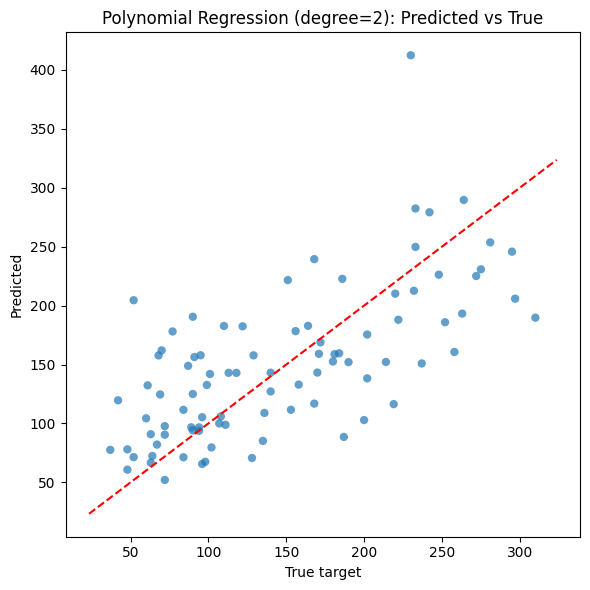

In [13]:

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Your code for model fit and predict here
polynomial = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)
polynomial.fit(X_train_std, y_train)
y_pred_poly = polynomial.predict(X_test_std)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly   = r2_score(y_test, y_pred_poly)

print("Polynomial Regression (degree=2):")
print(f"→ RMSE: {rmse_poly:.3f}")
print(f"→ R²:   {r2_poly:.3f}")


# Your code here for plot predicted vs. true
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_poly, alpha=0.7, edgecolor="none")
mn, mx = y_test.min(), y_test.max()
pad = 0.05*(mx - mn)
plt.plot([mn-pad, mx+pad], [mn-pad, mx+pad], 'r--')
plt.xlabel("True target")
plt.ylabel("Predicted")
plt.title("Polynomial Regression (degree=2): Predicted vs True")
plt.tight_layout()
plt.show()

## Task 3.3: k-Nearest Neighbors Regression (Nonparametric Model) (3 points)

In this task, we will fit a **nonparametric model** to the same dataset — the **k-Nearest Neighbors (kNN) Regression** model. Unlike polynomial or linear regression, kNN makes no assumptions about the functional form of the relationship between predictors and the target variable. Instead, it predicts the target value for a test sample by averaging the target values of the *k* training samples that are closest to it in feature space.  

1. Use the **standardized features** (`X_train_scaled`, `X_test_scaled`) since kNN relies on distance calculations and is sensitive to feature scale. Experiment with different values of *k* (for example, 3, 5, 10, 20, 50) to see how the model’s flexibility changes.  

2. After selecting the best-performing *k*, evaluate your final kNN model on the test set using **Root Mean Squared Error (RMSE)** and **R²**, as in the previous tasks. 

3. Finally, create a **scatter plot** of predicted versus true target values, adding a **45-degree line** (`y = x`) to indicate perfect predictions. 




In [14]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


k_values = [3, 5, 10, 20, 50]

# Your code here
results = []
for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_std, y_train)
    y_pred = model.predict(X_test_std)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append((k, rmse, r2))
    print(f"k={k:2d} → RMSE={rmse:.3f}, R²={r2:.3f}")

results_df = pd.DataFrame(results, columns=["k", "RMSE", "R2"])
best_row = results_df.loc[results_df["RMSE"].idxmin()]
best_k = int(best_row["k"])
print(f"Best k = {best_k} with RMSE={best_row['RMSE']:.3f} and R²={best_row['R2']:.3f}")

k= 3 → RMSE=57.333, R²=0.380
k= 5 → RMSE=55.204, R²=0.425
k=10 → RMSE=56.288, R²=0.402
k=20 → RMSE=55.212, R²=0.425
k=50 → RMSE=55.069, R²=0.428
Best k = 50 with RMSE=55.069 and R²=0.428


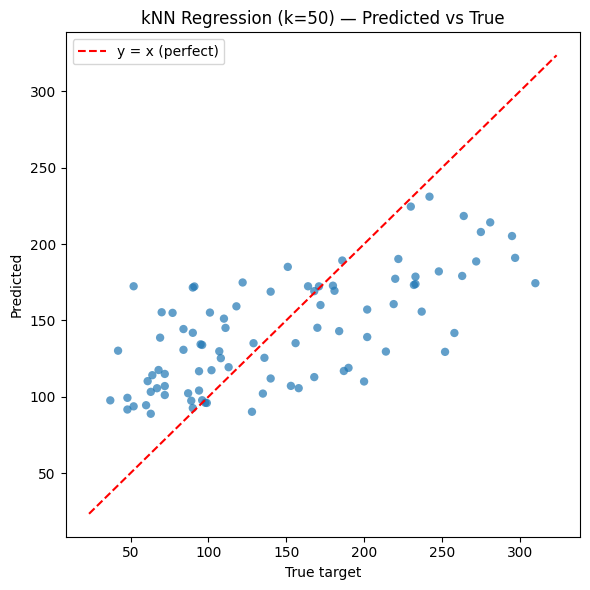

In [15]:
best_knn = KNeighborsRegressor(n_neighbors=best_k)
best_knn.fit(X_train_std, y_train)
y_pred_best = best_knn.predict(X_test_std)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best, alpha=0.7, edgecolor="none")
mn, mx = y_test.min(), y_test.max()
pad = 0.05 * (mx - mn)
plt.plot([mn-pad, mx+pad], [mn-pad, mx+pad], 'r--', label="y = x (perfect)")
plt.xlabel("True target")
plt.ylabel("Predicted")
plt.title(f"kNN Regression (k={best_k}) — Predicted vs True")
plt.legend()
plt.tight_layout()
plt.show()

## Task 3.4: Reflection (2 points)


Now that you have visualized the predictions from both models (Polynomial Regression and kNN Regression), take a few minutes to reflect on the results and answer the following questions:

1. From the observed plots, which model would you prefer and why?  
   Consider how closely the predictions align with the 45-degree line, as well as whether one model appears to systematically under- or over-predict certain ranges of target values.

2. As the number of data points increases, how do you expect the performance of the **kNN model** to change compared to the **Polynomial Regression** model?   Think about computational cost, smoothness of predictions, and generalization ability.

3. Suppose you are modeling a process where you have *strong prior knowledge* that relationships between variables are mostly linear (e.g., predicting fuel efficiency from weight and horsepower). Which approach would you choose, and why? Now imagine you are modeling a *complex, nonlinear phenomenon*.  Which model would be better suited, and what trade-offs would you need to consider?

5.   Both Polynomial Regression and kNN can overfit, but they do so in different ways.  Explain how **overfitting manifests** in each method, and what strategies can be used to control it.



#### Answer
1. Preferred model is Polynomial Regression. Because it produces predictions more symmetrically distributed around the ideal line, giving a more balanced and locally accurate fit to the data.
2. With much more data, kNN’s accuracy can surpass low-degree polynomials on nonlinear structure, but at higher compute and memory cost. Polynomials scale cheaply but risk persistent bias if the degree is inappropriate.
   - KNN
     - As the number of data points increases, performance Typically improves and it becomes smoother for the same k because each neighborhood contains more informative neighbors.
     - Prediction cost grows with n, time O(nd) and memory O(n).
   - Polynomial Regression
     - As the number of data points increases, performance also improves.
     - Although it globally smooth by design, it may still remain biased even with lots of data if degree is too low.
     - Prediction cost grows with n.
3.     
   - If the relationship is primarily linear, Choosing a polynomial model. Because its coefficients are interpretable, stable and efficient.
   - If the relationship is complex and nonlinear, Choosing kNN. Because it can capture arbitrary shapes without specifying a form.
5.      
   - Overfitting
     - Polynomial Regression: High degrees can create large, wiggly surfaces
     - kNN: Small k can make highly piecewise-constant predictions that follow noise
   - Solution
     - Polynomial Regression: We can Cross-validate the degree, use feature selection and standardization, and use Ridge or Lasso to shrink coefficients
     - kNN: We can Cross-validate the k and reduce dimension (PCA) or remove irrelevant features